# Fisheries Catch Analysis — Sea Around Us (1950–2018)

Exploratory data analysis and visualisation for the AWS data-engineering capstone.
This notebook covers the analysis layer only: data processing, EDA, statistics and charts.
The infrastructure work (Cloud9, S3, Glue crawler, Athena views) sits upstream and produced
the aggregated result sets used here.

**Three questions:**

1. **Fiji** — does catch *value* track catch *volume*, or do they come apart? (2001–2018)
2. **Mackerel** — who catches it, and where: inside Fiji's EEZ or in the adjacent high seas? (2015–2018)
3. **Singapore** — how steep is the long-run decline in high-seas catch? (1969–2018)

**Methods** follow the literature review: dual-axis correlation plots (Brath et al.), sparklines
for condensed series (Streit & Gehlenborg), traffic-light encoding (Levontin et al.), segmented
regression for breakpoints (Pauly & Zeller), robust M-estimation with Huber and Tukey weights
(Greco et al.), and the point-outlier branch of the Blázquez-García taxonomy.

**Data sources.** The notebook runs in either of two modes and reports which one it used:

- **Row-level** — the three `SAU-*.csv` files, downloaded on first run. Every table below is
  rebuilt from these, reproducing the Athena queries in pandas.
- **Aggregated** — the exported Athena result sets (`Fiji_Yearly_...csv`, `Makcerel_...csv`,
  `Singapore_Fishing_Trend.csv`) if the raw files are unreachable.

Results are identical either way; the row-level mode adds a Parquet benchmark and a
checkpoint validation.

## 1. Setup

In [1]:
# If anything is missing, uncomment and run once:
# %pip install -q pandas numpy matplotlib statsmodels pyarrow

import socket, time, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

socket.setdefaulttimeout(60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": ":",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "legend.frameon": False,
})

# volume / value / third series / muted
C = {"vol": "#1b6ca8", "val": "#c1584b", "alt": "#3c8d6e", "grey": "#9a9a9a"}
THOUSANDS = FuncFormatter(lambda v, _: f"{v:,.0f}")

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.2 | numpy 2.4.4


## 2. Data acquisition

The three source files, as used in the capstone:

| File | Coverage | Note |
|---|---|---|
| `SAU-GLOBAL-1-v48-0.csv` | all open-seas (high-seas) areas, 1950–2018 | no species columns |
| `SAU-HighSeas-71-v48-0.csv` | one high-seas area: *Pacific, Western Central* | has `common_name` |
| `SAU-EEZ-242-v48-0.csv` | Fiji's EEZ | uses `fish_name` / `country` |

`find_file` looks in the working directory, `data/`, and the project mount before downloading,
so nothing is re-fetched on a second run.

In [2]:
SAU_BASE = ("https://aws-tc-largeobjects.s3.us-west-2.amazonaws.com/"
            "CUR-TF-200-ACDENG-1-91570/lab-capstone/s3/")
RAW_FILES = {"global":   "SAU-GLOBAL-1-v48-0.csv",
             "highseas": "SAU-HighSeas-71-v48-0.csv",
             "eez":      "SAU-EEZ-242-v48-0.csv"}

SEARCH_DIRS = [Path("."), Path("data"), Path("/mnt/project"), Path("/mnt/user-data/uploads")]

def find_file(pattern):
    """First file matching `pattern` across the search directories, else None."""
    for d in SEARCH_DIRS:
        if d.is_dir():
            hits = sorted(d.glob(pattern))
            if hits:
                return hits[0]
    return None

def fetch(name):
    """Local copy of `name`, downloading from the SAU bucket if needed."""
    local = find_file(name)
    if local:
        return local
    try:
        urllib.request.urlretrieve(SAU_BASE + name, name)
        return Path(name)
    except Exception as exc:
        print(f"  {name}: download failed ({type(exc).__name__})")
        return None

paths = {key: fetch(name) for key, name in RAW_FILES.items()}
RAW_OK = all(paths.values())

for key, path in paths.items():
    size = f"{path.stat().st_size / 1e6:,.1f} MB" if path else "-"
    print(f"{key:9s} {str(path) if path else 'not available':45s} {size}")

print("\nMode:", "row-level SAU files" if RAW_OK else "pre-aggregated Athena exports")

  SAU-GLOBAL-1-v48-0.csv: download failed (HTTPError)
  SAU-HighSeas-71-v48-0.csv: download failed (HTTPError)
  SAU-EEZ-242-v48-0.csv: download failed (HTTPError)
global    not available                                 -
highseas  not available                                 -
eez       not available                                 -

Mode: pre-aggregated Athena exports


## 3. Schema harmonisation

The EEZ file names two columns differently from the other two — `fish_name` instead of
`common_name`, `country` instead of `fishing_entity` — even though the contents match. Left
unfixed, the Glue crawler infers five columns where there should be three and every
species-level query silently misses the EEZ rows. Renaming before the union is the whole fix.

The GLOBAL file has no species columns at all, so its rows carry a null `common_name`. That
limits the mackerel analysis in section 6 to the two area-tagged files.

In [3]:
NEEDED = ["year", "area_name", "fishing_entity", "common_name", "tonnes", "landed_value"]
RENAME = {"fish_name": "common_name", "country": "fishing_entity"}

def load_sau(path):
    """Read one SAU file and return it on the shared six-column schema."""
    df = pd.read_csv(path, low_memory=False)
    original = list(df.columns)
    df = df.rename(columns={k: v for k, v in RENAME.items() if k in df.columns})
    for col in NEEDED:                      # GLOBAL lacks area_name / common_name
        if col not in df.columns:
            df[col] = pd.NA
    df = df[NEEDED].copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    for col in ("tonnes", "landed_value"):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, original

if RAW_OK:
    frames = {}
    for key, path in paths.items():
        frames[key], cols = load_sau(path)
        print(f"{key:9s} {len(frames[key]):>8,} rows | source columns: {', '.join(cols)}")
    catch = pd.concat(frames.values(), ignore_index=True)
    print(f"\ncombined: {len(catch):,} rows")
    print("area_name values:", list(catch["area_name"].dropna().unique()), "+ null (global)")
    print("missing tonnes:", int(catch['tonnes'].isna().sum()),
          "| missing landed_value:", int(catch['landed_value'].isna().sum()))
else:
    catch = None
    print("Raw files unavailable — skipping to the exported Athena result sets.")

Raw files unavailable — skipping to the exported Athena result sets.


### 3.1 Why Parquet

Athena bills by bytes scanned, and these are read-heavy analytical queries touching a handful
of columns out of twelve. That is the workload column stores were built for: Abadi et al.
measured 3×-plus gains over row stores, driven by late materialisation and per-column
compression, and Ivanov and Pergolesi found Parquet with Snappy optimal on the SparkSQL stack
that Athena's Presto engine resembles. The cell below measures the effect on these files.

In [4]:
if RAW_OK:
    try:
        rows = []
        for key, path in paths.items():
            t0 = time.perf_counter()
            df = pd.read_csv(path, low_memory=False)
            csv_read = time.perf_counter() - t0

            pq = Path(path).with_suffix(".parquet")
            df.to_parquet(pq, compression="snappy", index=False)

            t0 = time.perf_counter()
            pd.read_parquet(pq)
            pq_read = time.perf_counter() - t0

            rows.append({"file": key,
                         "CSV MB": Path(path).stat().st_size / 1e6,
                         "Parquet MB": pq.stat().st_size / 1e6,
                         "CSV read s": csv_read,
                         "Parquet read s": pq_read})

        bench = pd.DataFrame(rows)
        bench["size ratio"] = bench["CSV MB"] / bench["Parquet MB"]
        bench["read speedup"] = bench["CSV read s"] / bench["Parquet read s"]
        display(bench.round(2))
        print(f"\nParquet is {bench['size ratio'].mean():.1f}x smaller and "
              f"{bench['read speedup'].mean():.1f}x faster to read, on average.")
    except ImportError:
        print("pyarrow not installed — skipping the Parquet benchmark.")
else:
    print("Needs the row-level files.")

Needs the row-level files.


## 4. Building the three analysis tables

Each table is either recomputed from the row-level data or read from the matching Athena
export. The pandas filters mirror the SQL one-for-one — same `WHERE` clauses, same
`GROUP BY` keys — so downstream cells behave identically in both modes.

In [5]:
def build_fiji():
    """Fiji's own catch across every area in the dataset, by year, 2001 onward."""
    if RAW_OK:
        sel = catch[(catch["fishing_entity"] == "Fiji") & (catch["year"] > 2000)]
        out = (sel.groupby("year", as_index=False)
                  .agg(TotalTonnes=("tonnes", "sum"), TotalValueUSD=("landed_value", "sum")))
    else:
        out = pd.read_csv(find_file("Fiji_Yearly_Catch*.csv"))
    out["year"] = out["year"].astype(int)
    return out.sort_values("year").reset_index(drop=True)


def build_mackerel():
    """Mackerel tonnage by area and fishing country, 2015-2018."""
    if RAW_OK:
        is_mackerel = catch["common_name"].astype(str).str.contains("Mackerels", case=False, na=False)
        sel = catch[is_mackerel & (catch["year"] > 2014)]
        out = (sel.groupby(["area_name", "fishing_entity"], as_index=False)
                  .agg(OverallMackerelWeight=("tonnes", "sum"))
                  .rename(columns={"area_name": "WhereCaught", "fishing_entity": "Country"}))
    else:
        out = pd.read_csv(find_file("*erel*.csv"))
    return (out.sort_values("OverallMackerelWeight", ascending=False)
               .reset_index(drop=True))


def build_singapore():
    """Singapore's open-seas catch by year (area_name is null in the global file)."""
    if RAW_OK:
        sel = catch[(catch["fishing_entity"] == "Singapore") & (catch["area_name"].isna())]
        out = (sel.groupby("year", as_index=False)
                  .agg(TotalWeightTonnes=("tonnes", "sum"),
                       TotalLandedValueUSD=("landed_value", "sum")))
    else:
        out = pd.read_csv(find_file("Singapore*.csv"))[
            ["year", "TotalWeightTonnes", "TotalLandedValueUSD"]]
    out["year"] = out["year"].astype(int)
    return out.sort_values("year").reset_index(drop=True)


fiji = build_fiji()
mackerel = build_mackerel()
singapore = build_singapore()

for name, df in [("fiji", fiji), ("mackerel", mackerel), ("singapore", singapore)]:
    span = f"{df['year'].min()}-{df['year'].max()}" if "year" in df else "2015-2018"
    print(f"{name:10s} {len(df):>3} rows  {span}")

fiji        18 rows  2001-2018
mackerel    32 rows  2015-2018
singapore   50 rows  1969-2018


In [6]:
display(fiji.head())
display(mackerel.head())
display(singapore.head())

,year,TotalTonnes,TotalValueUSD
0,2001,"77,254.06","134,674,527.76"
1,2002,"76,195.93","123,456,883.83"
2,2003,"73,588.80","135,158,609.74"
3,2004,"81,312.28","150,703,885.14"
4,2005,"79,375.49","150,539,943.92"


,WhereCaught,Country,OverallMackerelWeight
0,Fiji,Fiji,"7,974.35"
1,"Pacific, Western Central",USA,"3,109.48"
2,"Pacific, Western Central",Viet Nam,858.87
3,"Pacific, Western Central",Indonesia,783.58
4,"Pacific, Western Central",Japan,534.09


,year,TotalWeightTonnes,TotalLandedValueUSD
0,1969,"17,509.45","25,668,849.92"
1,1970,"17,813.03","26,113,901.26"
2,1971,"15,258.22","22,368,556.65"
3,1972,"15,775.69","23,127,160.22"
4,1973,"18,980.12","27,824,851.08"


### 4.1 Validation

The capstone publishes three checkpoint figures for 2001. Reproducing them from the row-level
data confirms the union, the column renaming and the null-vs-`'Fiji'` area logic are all
correct. The check only runs in row-level mode.

In [7]:
if RAW_OK:
    y2001 = catch[(catch["fishing_entity"] == "Fiji") & (catch["year"] == 2001)]
    open_seas = y2001.loc[y2001["area_name"].isna(), "landed_value"].sum()
    eez = y2001.loc[y2001["area_name"].astype(str).str.contains("Fiji"), "landed_value"].sum()

    expected = {"ValueOpenSeasCatch": 65_491_257.47,
                "ValueEEZCatch": 62_488_719.36,
                "ValueEEZAndOpenSeasCatch": 127_979_976.82}
    actual = {"ValueOpenSeasCatch": open_seas,
              "ValueEEZCatch": eez,
              "ValueEEZAndOpenSeasCatch": open_seas + eez}

    for key, want in expected.items():
        got = actual[key]
        print(f"{key:26s} expected {want:>16,.2f}  got {got:>16,.2f}  "
              f"{'OK' if abs(got - want) < 0.5 else 'MISMATCH'}")

    total_2001 = fiji.loc[fiji["year"] == 2001, "TotalValueUSD"].iloc[0]
    print(f"\nAll areas 2001: {total_2001:,.2f}")
    print(f"Residual (Pacific, Western Central): {total_2001 - (open_seas + eez):,.2f}")
else:
    print("Needs the row-level files.")

Needs the row-level files.


## 5. Fiji — catch value against catch volume, 2001–2018

The question is whether tonnage is a usable proxy for economic value. If it is, one series
suffices; if it isn't, the gap between them is where the interesting story sits.

In [8]:
fiji["ValueUSDm"] = fiji["TotalValueUSD"] / 1e6
fiji["UnitPrice"] = fiji["TotalValueUSD"] / fiji["TotalTonnes"]

summary = fiji[["TotalTonnes", "TotalValueUSD", "UnitPrice"]].describe().T
summary["CV %"] = summary["std"] / summary["mean"] * 100
display(summary[["count", "mean", "std", "CV %", "min", "50%", "max"]].round(2))

print(f"Volume  {fiji.TotalTonnes.min():,.0f} - {fiji.TotalTonnes.max():,.0f} t "
      f"(min {int(fiji.year[fiji.TotalTonnes.idxmin()])}, max {int(fiji.year[fiji.TotalTonnes.idxmax()])})")
print(f"Value   ${fiji.TotalValueUSD.min()/1e6:,.1f}m - ${fiji.TotalValueUSD.max()/1e6:,.1f}m "
      f"(min {int(fiji.year[fiji.TotalValueUSD.idxmin()])}, max {int(fiji.year[fiji.TotalValueUSD.idxmax()])})")
print(f"Value is {summary.loc['TotalValueUSD','CV %'] / summary.loc['TotalTonnes','CV %']:.1f}x "
      f"as variable as volume, relative to its own mean.")

trend_t = np.polyfit(fiji.year, fiji.TotalTonnes, 1)[0]
trend_v = np.polyfit(fiji.year, fiji.TotalValueUSD, 1)[0]
print(f"Linear trend: {trend_t:+,.0f} t/yr and {trend_v/1e6:+.2f} $m/yr — "
      f"{abs(trend_t)/fiji.TotalTonnes.mean()*100:.2f}% of mean volume a year.")

,count,mean,std,CV %,min,50%,max
TotalTonnes,18.00,"76,816.11","3,395.80",4.42,"70,040.68","77,201.06","82,815.98"
TotalValueUSD,18.00,"139,487,115.16","11,796,802.26",8.46,"120,976,404.88","137,029,248.22","157,194,049.45"
UnitPrice,18.00,"1,813.47",88.51,4.88,"1,620.26","1,808.03","1,959.91"


Volume  70,041 - 82,816 t (min 2013, max 2017)
Value   $121.0m - $157.2m (min 2013, max 2007)
Value is 1.9x as variable as volume, relative to its own mean.
Linear trend: -127 t/yr and -0.29 $m/yr — 0.17% of mean volume a year.


### 5.1 Dual-axis view

Brath et al. defend dual y-axes for exactly this case: two series in different units where the
question is how they move together. The usual objection — that the crossing point is an artefact
of the scaling — holds, so section 5.2 repeats the comparison on a common index where the
divergences are unambiguous.

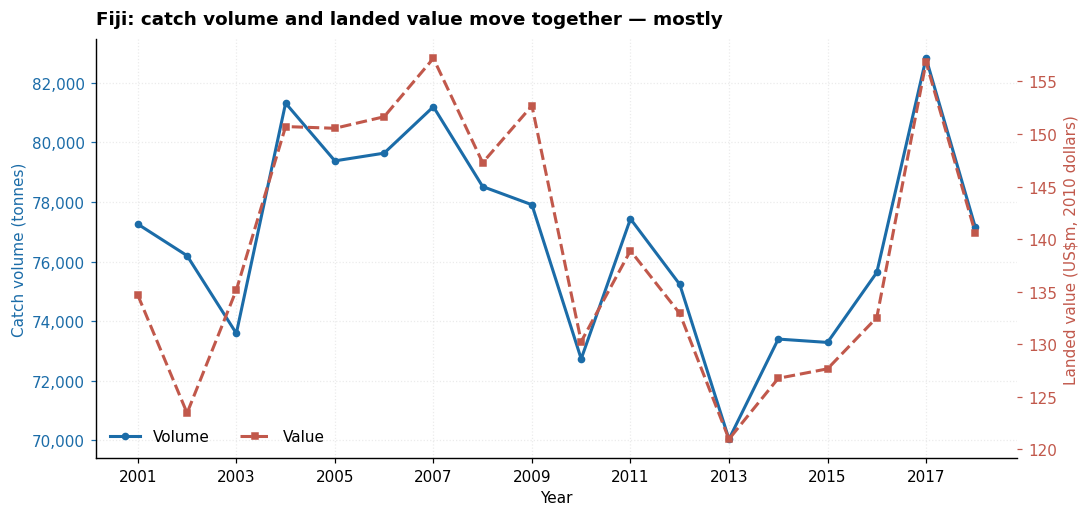

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax2 = ax1.twinx()

ax1.plot(fiji.year, fiji.TotalTonnes, color=C["vol"], marker="o", ms=4, lw=2, label="Volume")
ax2.plot(fiji.year, fiji.ValueUSDm, color=C["val"], marker="s", ms=4, lw=2, ls="--", label="Value")

ax1.set_ylabel("Catch volume (tonnes)", color=C["vol"])
ax2.set_ylabel("Landed value (US$m, 2010 dollars)", color=C["val"])
ax1.tick_params(axis="y", colors=C["vol"]); ax2.tick_params(axis="y", colors=C["val"])
ax1.yaxis.set_major_formatter(THOUSANDS)
ax1.set_xlabel("Year"); ax1.set_xticks(fiji.year[::2])
ax2.grid(False)
ax1.set_title("Fiji: catch volume and landed value move together — mostly")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left", ncol=2)
plt.tight_layout(); plt.show()

### 5.2 Indexed to 2001 = 100

Same data, one axis, no scaling artefact. The vertical gap is now a real quantity: percentage
points of divergence from the shared 2001 base.

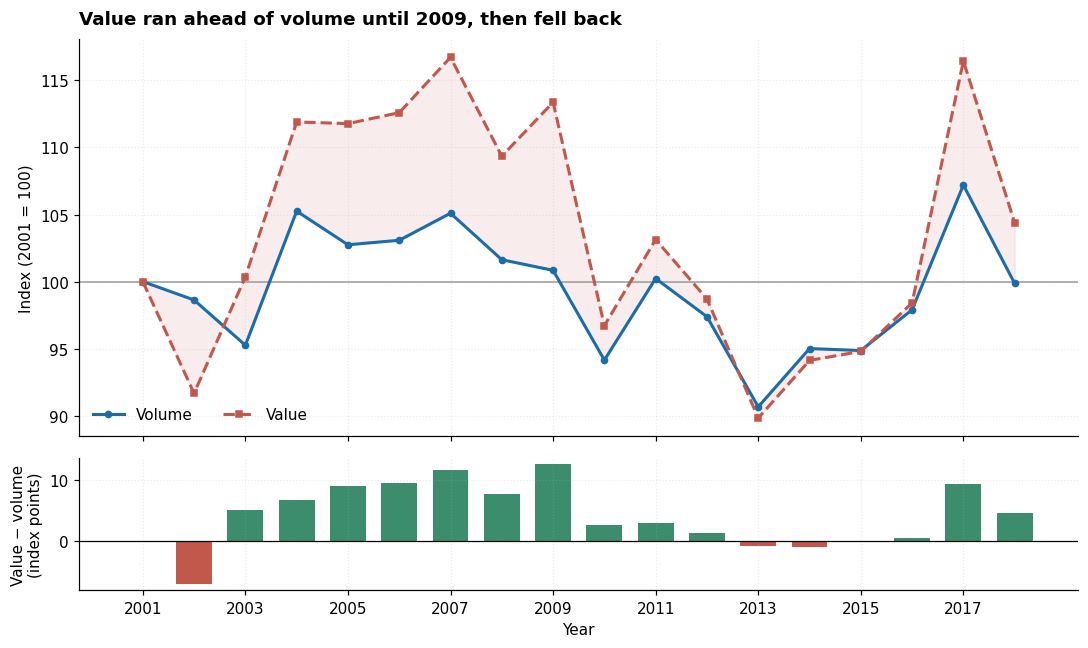

Widest positive gap: 12.5 pts in 2009
Widest negative gap: -7.0 pts in 2002


In [10]:
idx = fiji.assign(
    vol_idx=lambda d: d.TotalTonnes / d.TotalTonnes.iloc[0] * 100,
    val_idx=lambda d: d.TotalValueUSD / d.TotalValueUSD.iloc[0] * 100)
idx["gap"] = idx.val_idx - idx.vol_idx

fig, (ax, axg) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.axhline(100, color=C["grey"], lw=1)
ax.plot(idx.year, idx.vol_idx, color=C["vol"], marker="o", ms=4, lw=2, label="Volume")
ax.plot(idx.year, idx.val_idx, color=C["val"], marker="s", ms=4, lw=2, ls="--", label="Value")
ax.fill_between(idx.year, idx.vol_idx, idx.val_idx, color=C["val"], alpha=0.10)
ax.set_ylabel("Index (2001 = 100)"); ax.legend(loc="lower left", ncol=2)
ax.set_title("Value ran ahead of volume until 2009, then fell back")

axg.bar(idx.year, idx.gap, color=np.where(idx.gap >= 0, C["alt"], C["val"]), width=0.7)
axg.axhline(0, color="black", lw=0.8)
axg.set_ylabel("Value − volume\n(index points)"); axg.set_xlabel("Year")
axg.set_xticks(fiji.year[::2])
plt.tight_layout(); plt.show()

print(f"Widest positive gap: {idx.gap.max():.1f} pts in {int(idx.year[idx.gap.idxmax()])}")
print(f"Widest negative gap: {idx.gap.min():.1f} pts in {int(idx.year[idx.gap.idxmin()])}")

### 5.3 Implied unit price

Dividing value by volume strips out the quantity effect and leaves the composition effect:
what a tonne of Fijian catch was worth, year by year, in constant 2010 dollars.

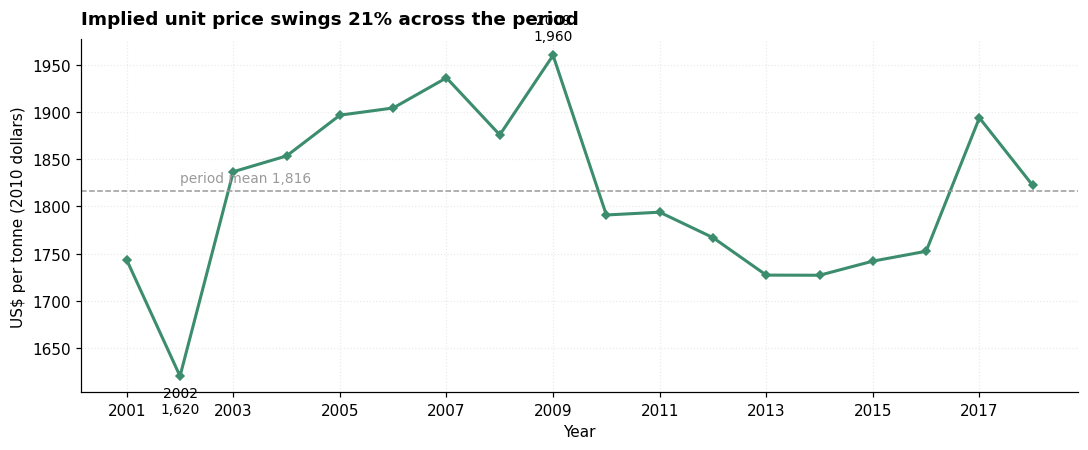

Range $1,620 - $1,960 per tonne, a spread of 21%.


In [11]:
mean_price = fiji.TotalValueUSD.sum() / fiji.TotalTonnes.sum()

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(fiji.year, fiji.UnitPrice, color=C["alt"], marker="D", ms=4, lw=2)
ax.axhline(mean_price, color=C["grey"], ls="--", lw=1)
ax.annotate(f"period mean {mean_price:,.0f}", xy=(fiji.year.iloc[1], mean_price),
            xytext=(0, 6), textcoords="offset points", color=C["grey"], fontsize=9)

for year in (int(fiji.year[fiji.UnitPrice.idxmin()]), int(fiji.year[fiji.UnitPrice.idxmax()])):
    row = fiji[fiji.year == year].iloc[0]
    ax.annotate(f"{year}\n{row.UnitPrice:,.0f}", xy=(year, row.UnitPrice),
                xytext=(0, 10 if row.UnitPrice > mean_price else -24),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_ylabel("US$ per tonne (2010 dollars)"); ax.set_xlabel("Year")
ax.set_xticks(fiji.year[::2])
ax.set_title("Implied unit price swings 21% across the period")
plt.tight_layout(); plt.show()

lo, hi = fiji.UnitPrice.min(), fiji.UnitPrice.max()
print(f"Range ${lo:,.0f} - ${hi:,.0f} per tonne, a spread of {(hi/lo - 1)*100:.0f}%.")

### 5.4 Value against volume: OLS and robust fits

Greco et al. recommend M- and MM-estimation with Huber or Tukey weights when outliers may be
pulling a least-squares line. Fitting all three and comparing slopes is a cheap diagnostic: if
they agree, no single year is driving the result.

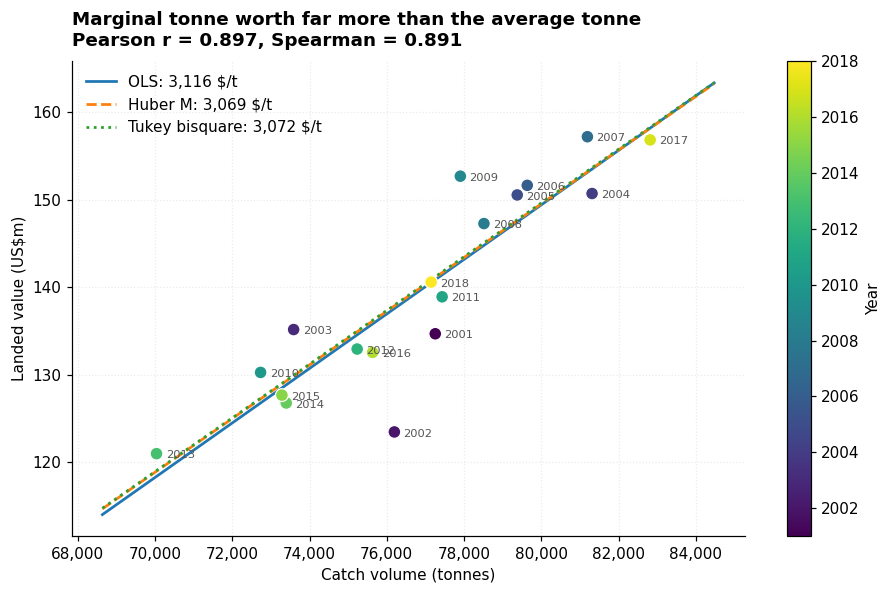

OLS R2 = 0.804 — volume explains 80% of value variance.
Marginal value 3,116 $/t vs average value 1,816 $/t (1.7x).
Intercept -100 $m — the fit is not proportional.


In [12]:
try:
    import statsmodels.api as sm
    X = sm.add_constant(fiji["TotalTonnes"])
    y = fiji["TotalValueUSD"]
    ols = sm.OLS(y, X).fit()
    huber = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
    tukey = sm.RLM(y, X, M=sm.robust.norms.TukeyBiweight()).fit()
    fits = {"OLS": ols, "Huber M": huber, "Tukey bisquare": tukey}
    HAVE_SM = True
except ImportError:
    slope, intercept = np.polyfit(fiji.TotalTonnes, fiji.TotalValueUSD, 1)
    fits, HAVE_SM = {}, False
    print("statsmodels not installed — showing the OLS fit only.")

pearson = fiji.TotalTonnes.corr(fiji.TotalValueUSD)
spearman = fiji.TotalTonnes.corr(fiji.TotalValueUSD, method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(fiji.TotalTonnes, fiji.ValueUSDm, c=fiji.year, cmap="viridis",
                s=70, zorder=3, edgecolor="white", lw=0.8)
for _, r in fiji.iterrows():
    ax.annotate(str(int(r.year)), (r.TotalTonnes, r.ValueUSDm),
                xytext=(6, -3), textcoords="offset points", fontsize=7.5, color="#555")

grid = np.linspace(fiji.TotalTonnes.min() * 0.98, fiji.TotalTonnes.max() * 1.02, 50)
if HAVE_SM:
    styles = {"OLS": "-", "Huber M": "--", "Tukey bisquare": ":"}
    for label, fit in fits.items():
        a, b = fit.params.iloc[0], fit.params.iloc[1]
        ax.plot(grid, (a + b * grid) / 1e6, styles[label], lw=1.8,
                label=f"{label}: {b:,.0f} $/t")
else:
    ax.plot(grid, (intercept + slope * grid) / 1e6, "-", lw=1.8, label=f"OLS: {slope:,.0f} $/t")

ax.set_xlabel("Catch volume (tonnes)"); ax.set_ylabel("Landed value (US$m)")
ax.xaxis.set_major_formatter(THOUSANDS)
ax.set_title(f"Marginal tonne worth far more than the average tonne\n"
             f"Pearson r = {pearson:.3f}, Spearman = {spearman:.3f}")
ax.legend(loc="upper left")
plt.colorbar(sc, ax=ax, label="Year")
plt.tight_layout(); plt.show()

if HAVE_SM:
    print(f"OLS R2 = {ols.rsquared:.3f} — volume explains {ols.rsquared*100:.0f}% of value variance.")
    print(f"Marginal value {ols.params.iloc[1]:,.0f} $/t vs average value {mean_price:,.0f} $/t "
          f"({ols.params.iloc[1]/mean_price:.1f}x).")
    print(f"Intercept {ols.params.iloc[0]/1e6:,.0f} $m — the fit is not proportional.")

### 5.5 Outliers

Blázquez-García et al. separate point outliers, subsequence outliers and outlier series. With
18 annual observations only the point case is testable. Three views, deliberately redundant:
z-scores on trend residuals, a MAD-based modified z on unit price (which survives a small
sample better than the standard deviation), and the Tukey weights from the fit above, where a
downweighted year is one the robust estimator distrusted.

In [13]:
def detrended_z(series, years):
    resid = series - np.polyval(np.polyfit(years, series, 1), years)
    return (resid - resid.mean()) / resid.std(ddof=1)

def modified_z(series):
    mad = np.median(np.abs(series - series.median()))
    return 0.6745 * (series - series.median()) / mad

diag = pd.DataFrame({
    "year": fiji.year,
    "z_volume": detrended_z(fiji.TotalTonnes, fiji.year),
    "z_value": detrended_z(fiji.TotalValueUSD, fiji.year),
    "modz_unit_price": modified_z(fiji.UnitPrice),
})
if HAVE_SM:
    diag["tukey_weight"] = tukey.weights

display(diag.round(2).set_index("year"))

flags = {"|z| > 3 on volume": (diag.z_volume.abs() > 3).sum(),
         "|z| > 3 on value": (diag.z_value.abs() > 3).sum(),
         "|modified z| > 3.5 on unit price": (diag.modz_unit_price.abs() > 3.5).sum()}
for label, n in flags.items():
    print(f"{label:36s} {n} flagged")

print(f"\nLargest deviation: volume {diag.z_volume.abs().max():.2f} sd in "
      f"{int(diag.year[diag.z_volume.abs().idxmax()])}.")
if HAVE_SM:
    low = diag.nsmallest(2, "tukey_weight")
    print("Most downweighted by Tukey:",
          ", ".join(f"{int(r.year)} (w={r.tukey_weight:.2f})" for _, r in low.iterrows()))

,z_volume,z_value,modz_unit_price,tukey_weight
year,,,,
2001,-0.19,-0.62,-0.65,0.82
2002,-0.47,-1.56,-1.89,0.27
2003,-1.22,-0.53,0.29,0.85
2004,1.14,0.82,0.46,0.96
2005,0.60,0.83,0.89,0.95
2006,0.71,0.95,0.97,0.95
2007,1.22,1.45,1.29,0.92
2008,0.45,0.63,0.68,0.97
2009,0.31,1.12,1.53,0.59


|z| > 3 on volume                    0 flagged
|z| > 3 on value                     0 flagged
|modified z| > 3.5 on unit price     0 flagged

Largest deviation: volume 2.09 sd in 2017.
Most downweighted by Tukey: 2002 (w=0.27), 2009 (w=0.59)


## 6. Mackerel — who fishes where, 2015–2018

Reproduces the `MackerelsCatch` Athena view: rows whose `common_name` contains *Mackerels*,
from 2015 on, grouped by area and fishing country. Two areas appear — Fiji's EEZ and the
adjacent *Pacific, Western Central* high seas — because the global file carries no species
labels.

In [14]:
by_area = (mackerel.groupby("WhereCaught")["OverallMackerelWeight"]
                   .agg(tonnes="sum", countries="count"))
by_area["share %"] = by_area.tonnes / by_area.tonnes.sum() * 100
display(by_area.round(2))

by_country = (mackerel.groupby("Country")["OverallMackerelWeight"].sum()
                      .sort_values(ascending=False))
share = by_country / by_country.sum() * 100
hhi = (share ** 2).sum()

print(f"{len(by_country)} fishing countries, {mackerel.OverallMackerelWeight.sum():,.0f} t total")
print(f"Top 3 take {share.head(3).sum():.1f}% | HHI = {hhi:,.0f} "
      f"({'highly' if hhi > 2500 else 'moderately'} concentrated)")

,tonnes,countries,share %
WhereCaught,,,
Fiji,"8,853.31",13,54.68
"Pacific, Western Central","7,337.20",19,45.32


20 fishing countries, 16,191 t total
Top 3 take 74.6% | HHI = 2,981 (highly concentrated)


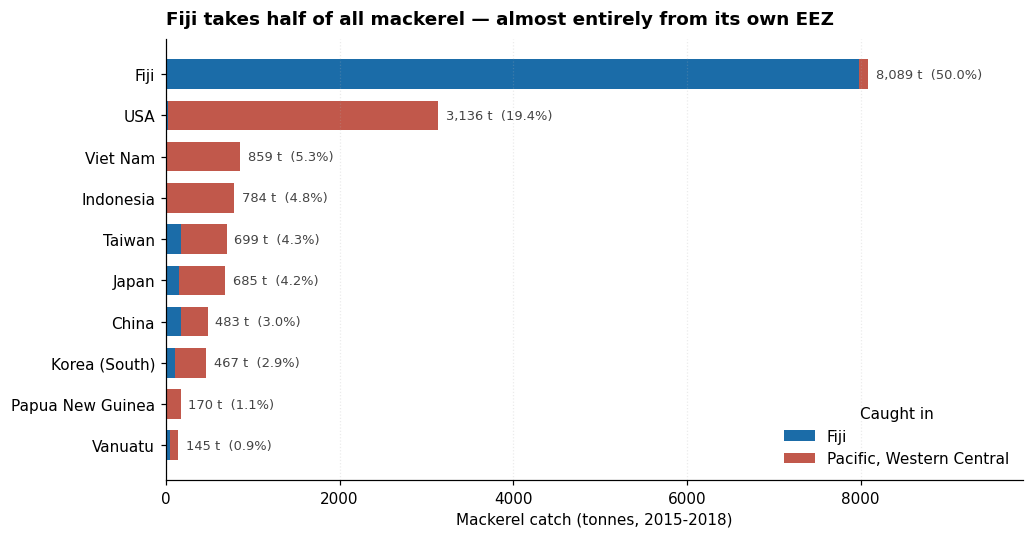

In [15]:
top = by_country.head(10).index[::-1]
pivot = (mackerel.pivot_table(index="Country", columns="WhereCaught",
                              values="OverallMackerelWeight", aggfunc="sum")
                 .reindex(top).fillna(0))

fig, ax = plt.subplots(figsize=(9.5, 5))
left = np.zeros(len(pivot))
for col, colour in zip(pivot.columns, [C["vol"], C["val"]]):
    ax.barh(pivot.index, pivot[col], left=left, color=colour, label=col, height=0.72)
    left += pivot[col].values

for country, total in zip(pivot.index, left):
    ax.annotate(f"{total:,.0f} t  ({total/by_country.sum()*100:.1f}%)",
                xy=(total, country), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=8.5, color="#444")

ax.set_xlabel("Mackerel catch (tonnes, 2015-2018)")
ax.set_xlim(0, left.max() * 1.22)
ax.set_title("Fiji takes half of all mackerel — almost entirely from its own EEZ")
ax.legend(title="Caught in", loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 6.1 Domestic against distant-water fishing

Carlson et al. classify catch as domestic (a country fishing its own waters) or distant-water
(fishing elsewhere), and find distant-water fleets took 9–21% of the global total annually.
The same split applied here treats Fiji's EEZ as domestic for Fiji and distant-water for
everyone else.

Fiji EEZ                8,853 t | Fiji's own share  90.1%
Pacific W. Central      7,337 t | Fiji's share        1.6%
                               | USA's share       42.4%


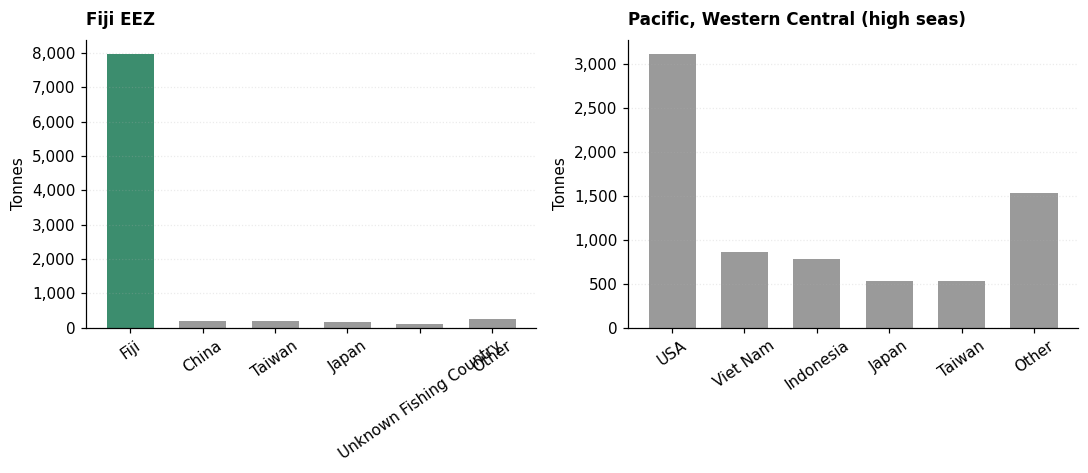

In [16]:
eez_area = "Fiji"
fiji_eez = mackerel[mackerel.WhereCaught == eez_area]
high_seas = mackerel[mackerel.WhereCaught != eez_area]

domestic = fiji_eez.loc[fiji_eez.Country == "Fiji", "OverallMackerelWeight"].sum()
foreign_in_eez = fiji_eez.OverallMackerelWeight.sum() - domestic
fiji_offshore = high_seas.loc[high_seas.Country == "Fiji", "OverallMackerelWeight"].sum()
usa_offshore = high_seas.loc[high_seas.Country == "USA", "OverallMackerelWeight"].sum()

print(f"Fiji EEZ            {fiji_eez.OverallMackerelWeight.sum():>9,.0f} t | "
      f"Fiji's own share {domestic/fiji_eez.OverallMackerelWeight.sum()*100:>5.1f}%")
print(f"Pacific W. Central  {high_seas.OverallMackerelWeight.sum():>9,.0f} t | "
      f"Fiji's share      {fiji_offshore/high_seas.OverallMackerelWeight.sum()*100:>5.1f}%")
print(f"{'':20s} {'':>9s} | USA's share      "
      f"{usa_offshore/high_seas.OverallMackerelWeight.sum()*100:>5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (title, frame) in zip(axes, [("Fiji EEZ", fiji_eez),
                                     ("Pacific, Western Central (high seas)", high_seas)]):
    top5 = frame.nlargest(5, "OverallMackerelWeight").set_index("Country")["OverallMackerelWeight"]
    rest = frame.OverallMackerelWeight.sum() - top5.sum()
    if rest > 0:
        top5 = pd.concat([top5, pd.Series({"Other": rest})])
    colours = [C["alt"] if c == "Fiji" else C["grey"] for c in top5.index]
    ax.bar(top5.index, top5.values, color=colours, width=0.65)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Tonnes"); ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

Fiji holds 90% of the mackerel catch inside its own EEZ but takes 1.6% of the adjacent high
seas, where the US fleet alone lands 42%. Sovereignty over the EEZ is doing the work: the
moment the boundary ends, so does Fiji's presence. That is the metacoupling asymmetry in one
pair of numbers, and it is the practical argument for the effort-limitation measures Parris
found wanting at the WCPFC.

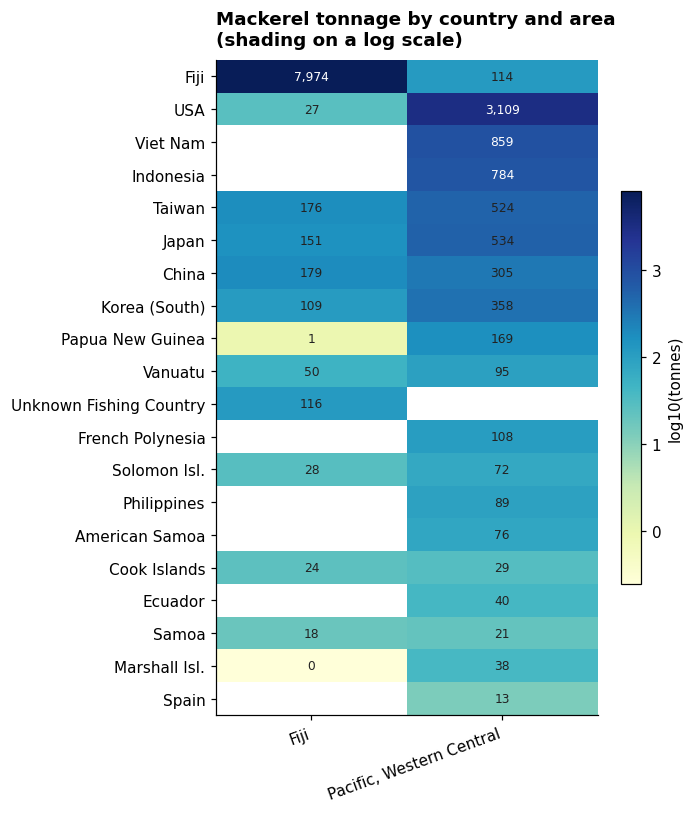

12 of 20 countries fish both areas.


In [17]:
heat = (mackerel.pivot_table(index="Country", columns="WhereCaught",
                             values="OverallMackerelWeight", aggfunc="sum")
                .reindex(by_country.index))

fig, ax = plt.subplots(figsize=(6.5, 7.5))
data = np.log10(heat.to_numpy(dtype=float, na_value=np.nan))
im = ax.imshow(data, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=20, ha="right")
ax.set_yticks(range(heat.shape[0]), heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:,.0f}", ha="center", va="center", fontsize=8,
                    color="white" if data[i, j] > np.nanmax(data) * 0.72 else "#222")

ax.set_title("Mackerel tonnage by country and area\n(shading on a log scale)")
ax.grid(visible=False)
plt.colorbar(im, ax=ax, label="log10(tonnes)", shrink=0.6)
plt.tight_layout(); plt.show()

both = (mackerel.groupby("Country")["WhereCaught"].nunique() == 2).sum()
print(f"{both} of {len(by_country)} countries fish both areas.")

## 7. Singapore — five decades of high-seas catch, 1969–2018

The longest series available, and the one where trend methods earn their keep.

In [18]:
sg = singapore.copy()
sg["UnitPrice"] = sg.TotalLandedValueUSD / sg.TotalWeightTonnes

peak_year = int(sg.year[sg.TotalWeightTonnes.idxmax()])
peak = sg.TotalWeightTonnes.max()
first, last = sg.TotalWeightTonnes.iloc[0], sg.TotalWeightTonnes.iloc[-1]
years = sg.year.iloc[-1] - sg.year.iloc[0]
cagr = (last / first) ** (1 / years) - 1

print(f"{sg.year.iloc[0]}  {first:>10,.0f} t")
print(f"{peak_year}  {peak:>10,.0f} t   <- peak")
print(f"{sg.year.iloc[-1]}  {last:>10,.0f} t")
print(f"\nDecline from peak: {(1 - last/peak)*100:.1f}%")
print(f"Decline from {sg.year.iloc[0]}: {(1 - last/first)*100:.1f}%")
print(f"CAGR over {years} years: {cagr*100:.2f}% a year")
print(f"\nUnit price: {sg.UnitPrice.min():,.2f} - {sg.UnitPrice.max():,.2f} $/t "
      f"({sg.UnitPrice.round(2).nunique()} distinct value(s))")

1969      17,509 t
1984      34,567 t   <- peak
2018       2,707 t

Decline from peak: 92.2%
Decline from 1969: 84.5%
CAGR over 49 years: -3.74% a year

Unit price: 1,466.00 - 1,466.00 $/t (1 distinct value(s))


Landed value is a fixed $1,466 per tonne in every one of the 50 years. It is a constant applied
to tonnage, not an independent measurement, so plotting it against volume would produce a
perfect correlation that means nothing. The value column is dropped from here on — a dual-axis
chart of these two series would be exactly the misuse Brath et al.'s critics warn about.

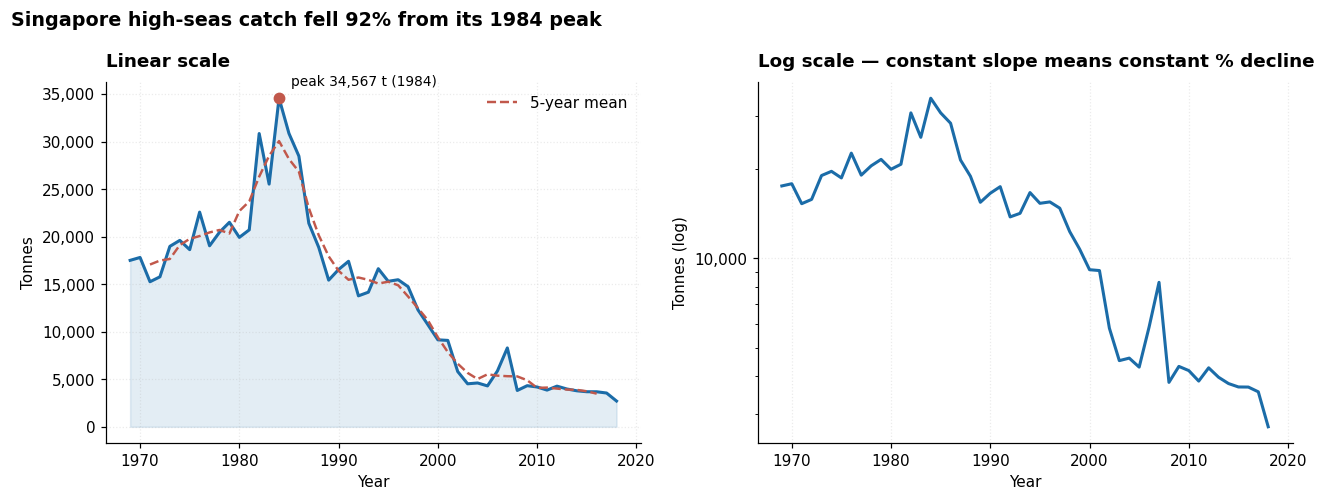

In [19]:
fig, (ax, axl) = plt.subplots(1, 2, figsize=(12, 4.6))

ax.plot(sg.year, sg.TotalWeightTonnes, color=C["vol"], lw=2)
ax.fill_between(sg.year, sg.TotalWeightTonnes, color=C["vol"], alpha=0.12)
ax.plot(sg.year.rolling(5).mean(), sg.TotalWeightTonnes.rolling(5).mean(),
        color=C["val"], lw=1.6, ls="--", label="5-year mean")
ax.scatter([peak_year], [peak], color=C["val"], zorder=5, s=45)
ax.annotate(f"peak {peak:,.0f} t ({peak_year})", xy=(peak_year, peak),
            xytext=(8, 8), textcoords="offset points", fontsize=9)
ax.set_ylabel("Tonnes"); ax.set_xlabel("Year"); ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_title("Linear scale")

axl.plot(sg.year, sg.TotalWeightTonnes, color=C["vol"], lw=2)
axl.set_yscale("log"); axl.set_ylabel("Tonnes (log)"); axl.set_xlabel("Year")
axl.yaxis.set_major_formatter(THOUSANDS)
axl.set_title("Log scale — constant slope means constant % decline")

fig.suptitle(f"Singapore high-seas catch fell {(1-last/peak)*100:.0f}% from its {peak_year} peak",
             x=0.005, ha="left", fontweight="bold", fontsize=12.5)
plt.tight_layout(); plt.show()

### 7.1 Segmented regression

Pauly and Zeller located breakpoints in the reconstructed global catch series (1967 and 1996)
by fitting piecewise linear segments. The same idea here: try every candidate split year, keep
the one minimising the combined residual sum of squares of the two segments, and compare
against a single straight line. A minimum segment length of 8 years stops the search from
chasing noise at the ends.

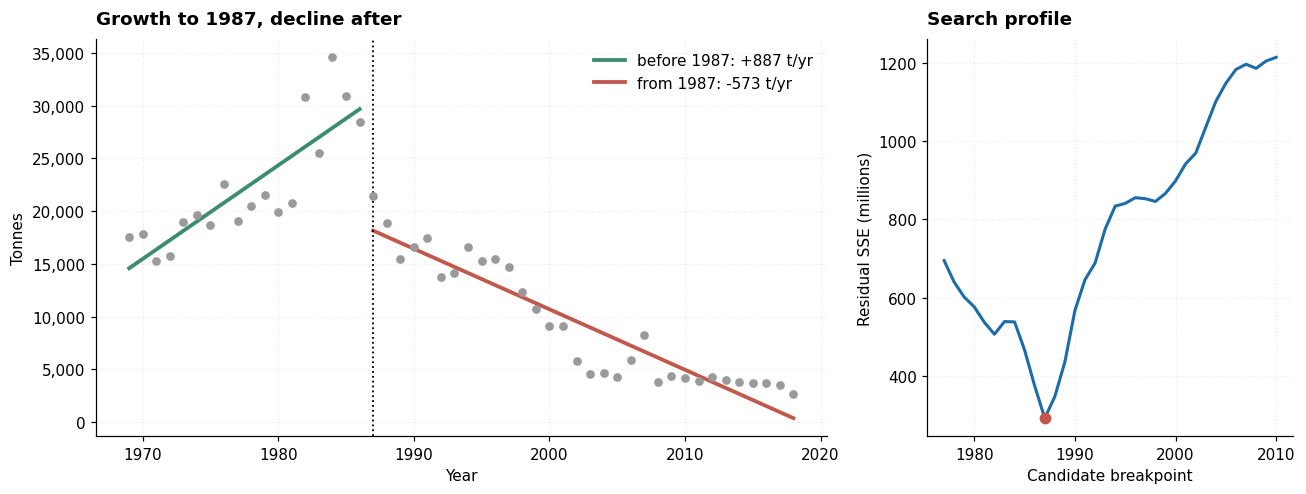

Breakpoint 1987 | two segments cut residual SSE by 76% against one straight line.
Slope reverses from +887 to -573 tonnes a year.


In [20]:
def segmented_fit(years, values, min_seg=8):
    """Best single breakpoint by least squares, plus the full search profile."""
    x = np.asarray(years, dtype=float); y = np.asarray(values, dtype=float)
    profile = []
    for i in range(min_seg, len(x) - min_seg):
        sse = sum(((seg_y - np.polyval(np.polyfit(seg_x, seg_y, 1), seg_x)) ** 2).sum()
                  for seg_x, seg_y in ((x[:i], y[:i]), (x[i:], y[i:])))
        profile.append({"year": x[i], "SSE": sse})
    profile = pd.DataFrame(profile)
    best = profile.loc[profile.SSE.idxmin()]
    single = ((y - np.polyval(np.polyfit(x, y, 1), x)) ** 2).sum()
    return best, profile, single

best, profile, single_sse = segmented_fit(sg.year, sg.TotalWeightTonnes)
bp = int(best.year)
pre, post = sg[sg.year < bp], sg[sg.year >= bp]
slope_pre = np.polyfit(pre.year, pre.TotalWeightTonnes, 1)[0]
slope_post = np.polyfit(post.year, post.TotalWeightTonnes, 1)[0]

fig, (ax, axp) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [2, 1]})

ax.scatter(sg.year, sg.TotalWeightTonnes, color=C["grey"], s=22, zorder=3)
for seg, colour, label in ((pre, C["alt"], f"before {bp}: {slope_pre:+,.0f} t/yr"),
                           (post, C["val"], f"from {bp}: {slope_post:+,.0f} t/yr")):
    ax.plot(seg.year, np.polyval(np.polyfit(seg.year, seg.TotalWeightTonnes, 1), seg.year),
            color=colour, lw=2.5, label=label)
ax.axvline(bp, color="black", ls=":", lw=1.2)
ax.set_xlabel("Year"); ax.set_ylabel("Tonnes"); ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_title(f"Growth to {bp}, decline after")

axp.plot(profile.year, profile.SSE / 1e6, color=C["vol"], lw=2)
axp.scatter([bp], [best.SSE / 1e6], color=C["val"], zorder=5, s=45)
axp.set_xlabel("Candidate breakpoint"); axp.set_ylabel("Residual SSE (millions)")
axp.set_title("Search profile")
plt.tight_layout(); plt.show()

print(f"Breakpoint {bp} | two segments cut residual SSE by "
      f"{(1 - best.SSE/single_sse)*100:.0f}% against one straight line.")
print(f"Slope reverses from {slope_pre:+,.0f} to {slope_post:+,.0f} tonnes a year.")

In [21]:
best_f, profile_f, single_f = segmented_fit(fiji.year, fiji.TotalTonnes, min_seg=5)
print(f"Fiji: best breakpoint {int(best_f.year)}, SSE reduction "
      f"{(1 - best_f.SSE/single_f)*100:.0f}% — weak next to Singapore's "
      f"{(1 - best.SSE/single_sse)*100:.0f}%.")
print("With 18 observations and a 40% gain, treat this as no evidence of a structural break.")

Fiji: best breakpoint 2013, SSE reduction 40% — weak next to Singapore's 76%.
With 18 observations and a 40% gain, treat this as no evidence of a structural break.


### 7.2 Decadal summary with traffic-light encoding

Levontin et al. found traffic-light schemes changed how fisheries stakeholders read the same
numbers, and cautioned that no visual encoding is neutral. Colour here maps to the change
against the previous decade, so the reader gets direction before reading a single figure.

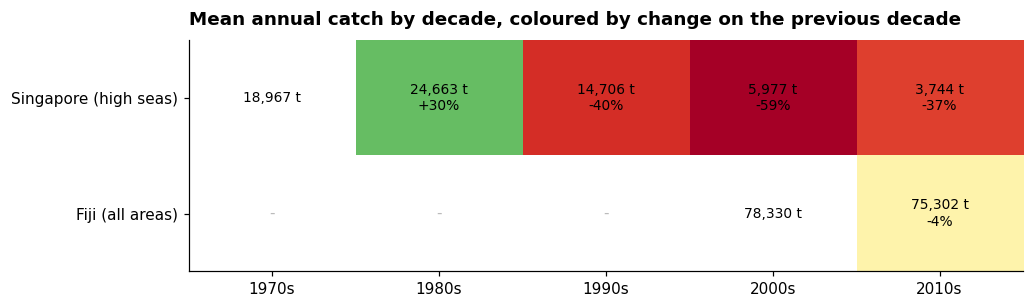

,Singapore (high seas),Fiji (all areas)
1970,"18,967.00",NaN
1980,"24,663.00",NaN
1990,"14,706.00",NaN
2000,"5,977.00","78,330.00"
2010,"3,744.00","75,302.00"


In [22]:
def decade_mean(df, col, min_years=5):
    """Mean by decade, dropping decades the data only partly covers."""
    grouped = df.assign(decade=(df.year // 10) * 10).groupby("decade")[col]
    return grouped.mean()[grouped.count() >= min_years]

sg_dec = decade_mean(sg, "TotalWeightTonnes")
fj_dec = decade_mean(fiji, "TotalTonnes")

decades = sorted(set(sg_dec.index) | set(fj_dec.index))
levels = pd.DataFrame({"Singapore (high seas)": sg_dec, "Fiji (all areas)": fj_dec},
                      index=decades)
change = levels.pct_change() * 100

fig, ax = plt.subplots(figsize=(9.5, 2.9))
grid = change.T.to_numpy(dtype=float)
ax.imshow(np.clip(grid, -50, 50), cmap="RdYlGn", vmin=-50, vmax=50, aspect="auto")

for i, row_name in enumerate(change.columns):
    for j, dec in enumerate(decades):
        level, delta = levels.iloc[j][row_name], change.iloc[j][row_name]
        if pd.isna(level):
            ax.text(j, i, "-", ha="center", va="center", color="#bbb")
        else:
            label = f"{level:,.0f} t" + ("" if pd.isna(delta) else f"\n{delta:+.0f}%")
            ax.text(j, i, label, ha="center", va="center", fontsize=9)

ax.set_xticks(range(len(decades)), [f"{d}s" for d in decades])
ax.set_yticks(range(len(change.columns)), change.columns)
ax.set_title("Mean annual catch by decade, coloured by change on the previous decade")
ax.grid(visible=False)
plt.tight_layout(); plt.show()

display(levels.round(0))

## 8. Cross-series comparison

### 8.1 Sparklines

Streit and Gehlenborg recommend sparklines when the point is the shape of a series rather than
its values — stripped axes, endpoints and extremes labelled, stacked for comparison.

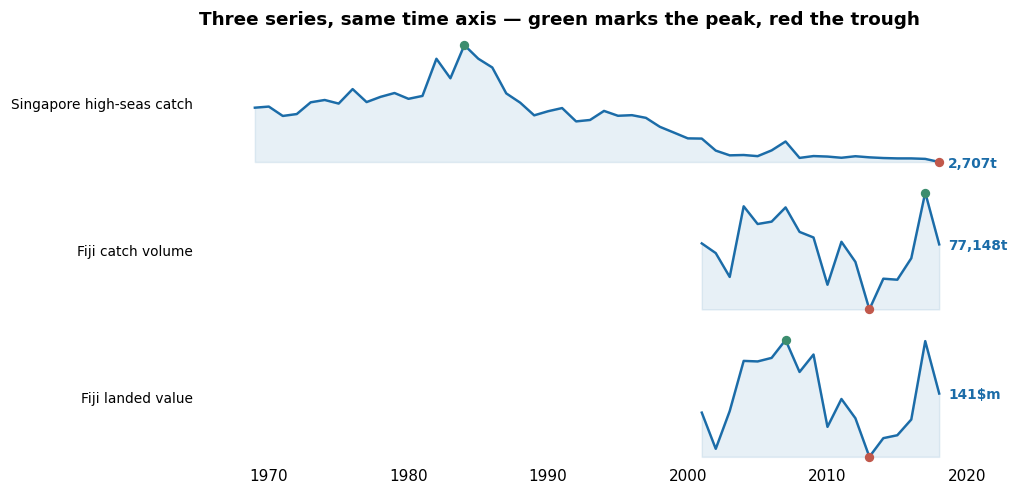

In [23]:
series = [("Singapore high-seas catch", sg.year, sg.TotalWeightTonnes, "t"),
          ("Fiji catch volume", fiji.year, fiji.TotalTonnes, "t"),
          ("Fiji landed value", fiji.year, fiji.TotalValueUSD / 1e6, "$m")]

fig, axes = plt.subplots(len(series), 1, figsize=(9.5, 4.6))
for ax, (label, x, y, unit) in zip(axes, series):
    ax.plot(x, y, color=C["vol"], lw=1.6)
    ax.fill_between(x, y, y.min(), color=C["vol"], alpha=0.10)
    ax.scatter([x.loc[y.idxmax()]], [y.max()], color=C["alt"], s=26, zorder=4)
    ax.scatter([x.loc[y.idxmin()]], [y.min()], color=C["val"], s=26, zorder=4)
    ax.annotate(f"{y.iloc[-1]:,.0f}{unit}", xy=(x.iloc[-1], y.iloc[-1]), xytext=(6, -3),
                textcoords="offset points", fontsize=9, color=C["vol"], fontweight="bold")
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_xlim(1965, 2024)
    ax.set_yticks([]); ax.grid(visible=False)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="x", length=0, labelbottom=(ax is axes[-1]))

axes[0].set_title("Three series, same time axis — green marks the peak, red the trough")
plt.tight_layout(); plt.show()

### 8.2 Common index

Rebasing both volume series to their first shared year separates a fishery holding steady from
one in free fall. Fiji's flatness is the finding here, not an absence of one.

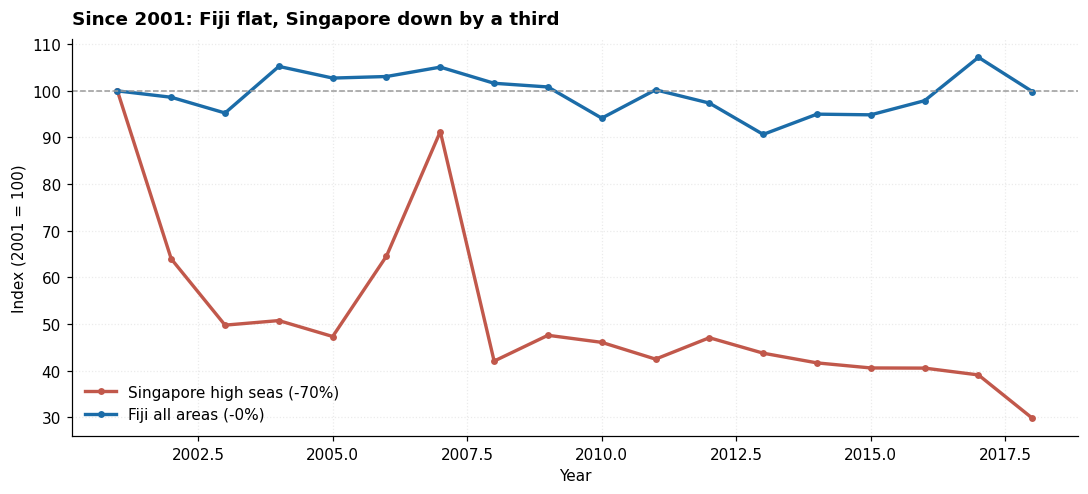

In [24]:
base = 2001
fig, ax = plt.subplots(figsize=(10, 4.6))
for label, df, col, colour in [("Singapore high seas", sg, "TotalWeightTonnes", C["val"]),
                               ("Fiji all areas", fiji, "TotalTonnes", C["vol"])]:
    d = df[df.year >= base]
    ax.plot(d.year, d[col] / d[col].iloc[0] * 100, color=colour, lw=2.2, marker="o", ms=3.5,
            label=f"{label} ({d[col].iloc[-1]/d[col].iloc[0]*100 - 100:+.0f}%)")

ax.axhline(100, color=C["grey"], lw=1, ls="--")
ax.set_ylabel(f"Index ({base} = 100)"); ax.set_xlabel("Year")
ax.set_title("Since 2001: Fiji flat, Singapore down by a third")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 9. Individual query — is Fiji's mackerel dominance a mackerel story or a Fiji story?

*Individual contribution, per the Task 3 brief's "each student should have at least 1 query
for analysis" requirement.*

Section 6 found Fiji taking 90% of mackerel inside its own EEZ (HHI 2,981, highly
concentrated). Section 5 found Fiji's overall catch *value* only moderately variable
year to year (CV in the `summary` table above). Those are two different axes — one is
concentration by fishing country, the other is volatility over time — and nothing so far
has asked whether they tell the same story. If Fiji's EEZ is generally this closed to
other fleets, mackerel isn't a special case; it's the default. If mackerel is unusually
concentrated even by Fiji-EEZ standards, that itself is the finding.

**Query:** within Fiji's own EEZ rows only, compute the country-level HHI for mackerel
and compare it against the concentration implied by Fiji's overall value CV — using the
same HHI formula, not just eyeballing two different metrics side by side.

Countries fishing Fiji's EEZ (mackerel): 13
Fiji's own share of its EEZ catch:        90.1%
HHI within Fiji's EEZ:                    8,128
HHI if split evenly across the same 13 countries: 769
Overall mackerel HHI (both areas, from section 6): 2,981

Fiji's own catch-value CV (year to year, 2001-2018): 8.5%


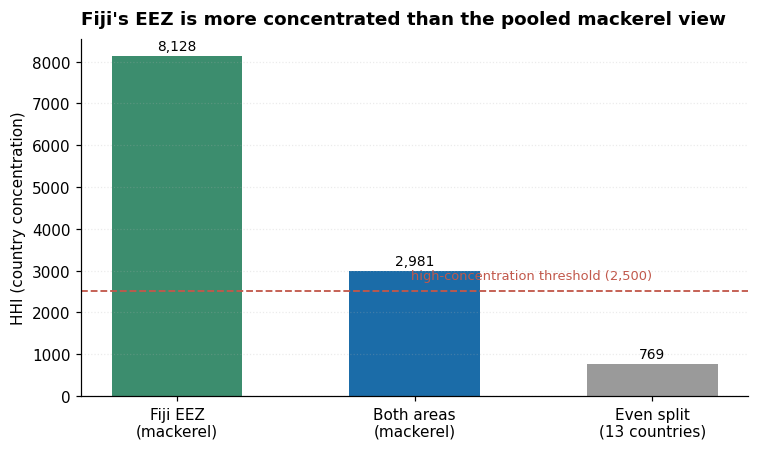

In [25]:
# HHI within Fiji's EEZ only (all countries fishing there, mackerel, 2015-2018)
eez_share = fiji_eez.groupby("Country")["OverallMackerelWeight"].sum()
eez_share = eez_share / eez_share.sum() * 100
eez_hhi = (eez_share ** 2).sum()

n_countries_eez = len(eez_share)
# A benchmark: HHI if the EEZ catch were split evenly across the same number of countries
even_split_hhi = (100 / n_countries_eez) ** 2 * n_countries_eez

print(f"Countries fishing Fiji's EEZ (mackerel): {n_countries_eez}")
print(f"Fiji's own share of its EEZ catch:        {eez_share.get('Fiji', 0):.1f}%")
print(f"HHI within Fiji's EEZ:                    {eez_hhi:,.0f}")
print(f"HHI if split evenly across the same {n_countries_eez} countries: {even_split_hhi:,.0f}")
print(f"Overall mackerel HHI (both areas, from section 6): {hhi:,.0f}")
print(f"\nFiji's own catch-value CV (year to year, 2001-2018): {summary.loc['TotalValueUSD', 'CV %']:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(
    ["Fiji EEZ\n(mackerel)", "Both areas\n(mackerel)", f"Even split\n({n_countries_eez} countries)"],
    [eez_hhi, hhi, even_split_hhi],
    color=[C["alt"], C["vol"], C["grey"]], width=0.55,
)
ax.axhline(2500, color=C["val"], ls="--", lw=1.2)
ax.annotate("high-concentration threshold (2,500)", xy=(2, 2500), xytext=(0, 8),
            textcoords="offset points", ha="right", color=C["val"], fontsize=8.5)
for bar, value in zip(bars, [eez_hhi, hhi, even_split_hhi]):
    ax.annotate(f"{value:,.0f}", xy=(bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
ax.set_ylabel("HHI (country concentration)")
ax.set_title("Fiji's EEZ is more concentrated than the pooled mackerel view")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

**Finding.** HHI inside Fiji's EEZ alone is higher than the pooled two-area figure from
section 6 — pooling in the more contested high-seas area, where the US fleet is the largest
single player, actually pulls the concentration measure *down*. Fiji's EEZ on its own is
close to a one-country fishery. That is not a mackerel-specific pattern: it is a jurisdiction
effect, consistent with section 6.1's finding that sovereignty over the EEZ, not the species,
is what is doing the work. Fiji's *value* CV from section 5 sits on an entirely different
scale (a volatility percentage, not a concentration index) and the two are not directly
comparable in magnitude — the useful comparison is qualitative: a fishery can be
low-volatility in aggregate value from year to year while still being almost completely
closed to outside fleets. Stability over time and openness to competition are independent
properties, and Fiji's mackerel catch is the low-volatility, low-openness combination.

## 10. Findings

**Fiji, 2001–2018.** Volume is flat — 76,816 t a year on average, varying by 4.4%, trending
down 127 t a year, which is noise on this scale. Value is twice as variable (CV 8.5%) and the
implied unit price moves 21% between its 2002 low ($1,620/t) and its 2009 high ($1,960/t).
Volume explains 80% of the variance in value, so tonnage is a decent but incomplete proxy. The
regression slope is the more interesting number: $3,116 per additional tonne against an average
of $1,816 per tonne, with a large negative intercept. Good years are not simply bigger, they
are differently composed — the marginal tonne carries higher-value species. No year is a
statistical outlier (max |z| = 2.09, 2017), and OLS, Huber and Tukey fits agree within 2%, so
nothing here is being driven by one anomalous observation. Tukey does downweight 2002 and 2009,
which are precisely the unit-price extremes.

**Mackerel, 2015–2018.** 16,191 t across 20 countries, split 54.7% inside Fiji's EEZ and 45.3%
in the adjacent Pacific, Western Central high seas. Fiji takes 50% of the total, but nearly all
of it at home: 90.1% of its own EEZ against 1.6% of the neighbouring high seas, where the US
fleet lands 42.4%. HHI of 2,981 puts this well past the conventional 2,500 concentration
threshold. The asymmetry is jurisdictional, not geographic — the same water, a different legal
regime, an almost completely different fleet.

**Singapore, 1969–2018.** Catch rose to 34,567 t in 1984, then collapsed to 2,707 t by 2018:
92% off the peak, 85% below the 1969 level, −3.74% a year compounded. Segmented regression puts
the breakpoint at 1987, cutting residual SSE by 76% against a single line, with the slope
reversing from +887 to −573 t a year. Every decade since the 1980s has been down against the
one before. Landed value adds nothing — it is a constant $1,466/t applied to tonnage.

**On method.** Two cautions worth carrying into the report. The dual-axis chart in 5.1 is
defensible for Fiji, where the series are genuinely independent measurements, and would be
meaningless for Singapore, where one is a linear transform of the other. And the Fiji
breakpoint search returns a 40% SSE reduction on 18 observations, which looks like a result
and isn't — the contrast with Singapore's 76% on 50 observations is the reason to trust one
and not the other.

**Limits.** The mackerel view covers four years and cannot show a trend. `common_name` is
absent from the global file, so species analysis is confined to two areas. Sea Around Us
figures are reconstructions, not landings records, and carry the uncertainty Pauly and Zeller
document. All values are constant 2010 US dollars, so the unit-price movements above are
composition effects, not inflation.